In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from utils import * #only needed for xgboost
from friedman1 import *

In [2]:
#Function that returns best params for each pair of (d, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['d', 'seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('val_rmse','mean'),
                avg_mae=('val_mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse')
    topk_df = agg.groupby(['d'], group_keys=False).head(k)
    topk_d = topk_df[['d', 'method', 'avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df




In [7]:
# For gaussian errors, we simply combine previous results with LAD results
data_gaussian = pd.read_csv('results/200_gaussian.csv')
data_gaussian = pd.read_csv('results/gaussian.csv')

# For slash errors
data_slash = pd.read_csv('results/200_slash.csv')
data_slash = pd.read_csv('results/slash.csv')
# data_slash = data_slash[(data_slash['seed'] != 79)
#                           & (data_slash['seed'] != 78)
#                           & (data_slash['seed'] != 77)]
#                          & (data_slash['d'] != 7)
#                          & (data_slash['d'] != 6)]

#data_slash = data_slash[data_slash['seed'] != 52]
# For slash errors
data_t= pd.read_csv('results/200_t.csv')
data_t= pd.read_csv('results/t.csv')
# data_t = data_t[(data_t['seed'] != 79)]
#                 (data_t['d'] != 9)]

# data_t = data_t[data_t['seed'] != 52]

In [8]:

# Here we find the optimal settings
LS_data_gaussian = data_gaussian[data_gaussian['method'] == 'LSTransferTreeBoost']
LAD_data_gaussian = data_gaussian[data_gaussian['method'] == 'LADTransferTreeBoost']
Huber_data_gaussian = data_gaussian[data_gaussian['method'] == 'MTransferTreeBoost']

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_gaussian,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_gaussian,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_gaussian,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

#create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])




Text(0, 0.5, 'RMSE')

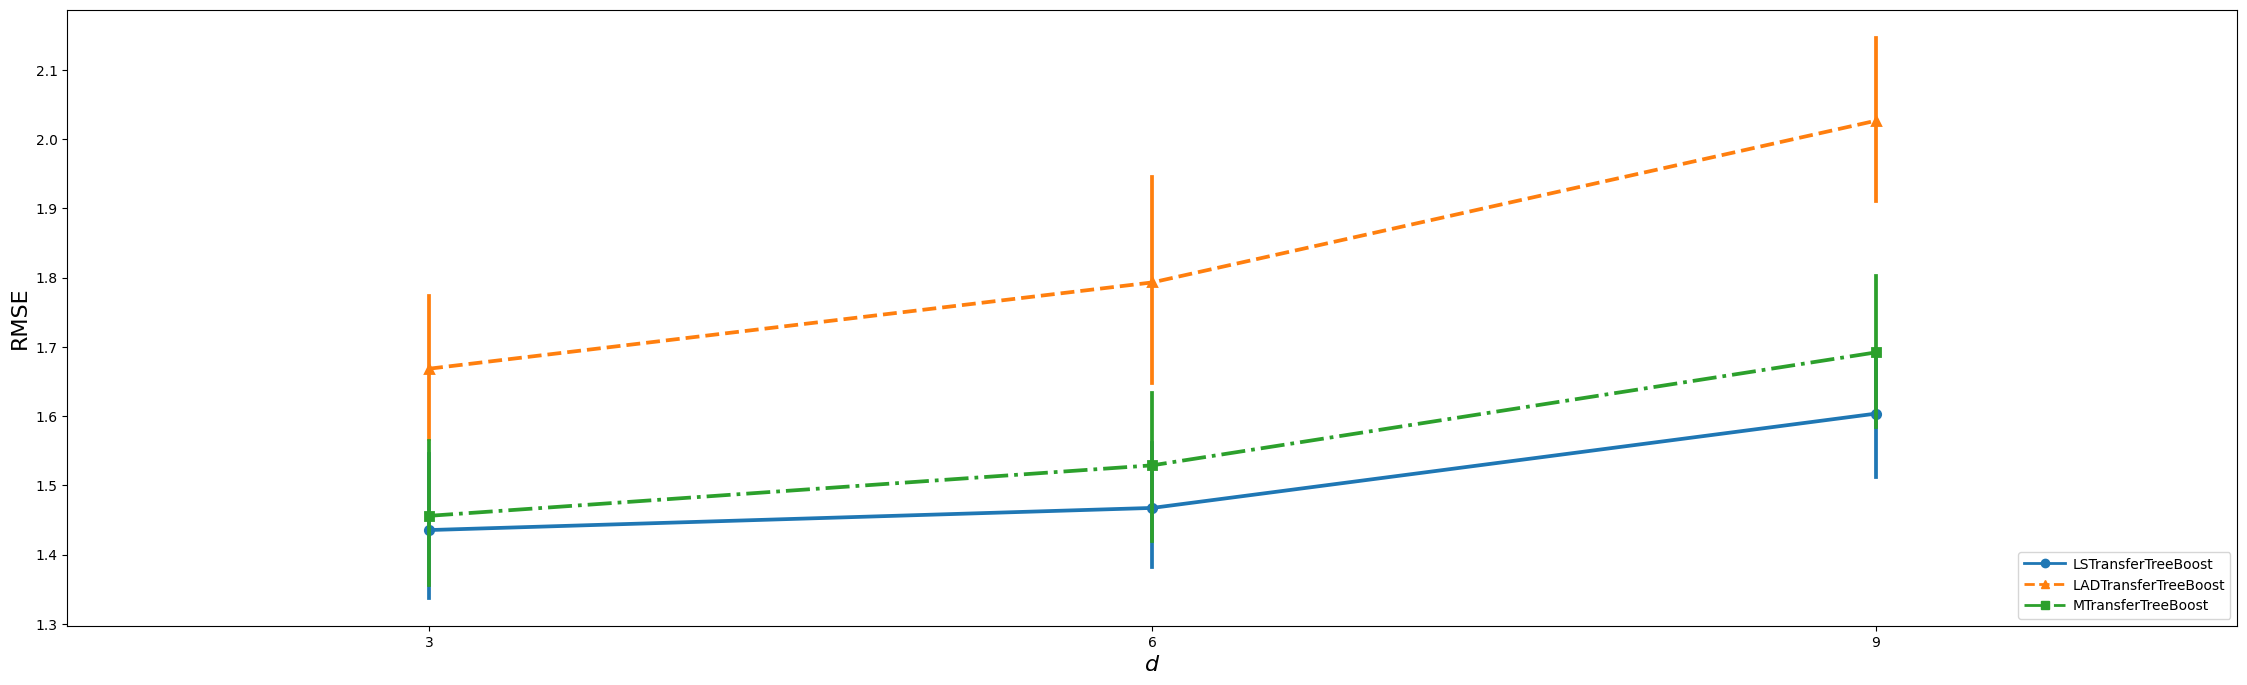

In [9]:
# Plot average test RMSE:s for best hyperparams
from matplotlib.lines import Line2D

plt.figure(figsize = (28,8))
sns.pointplot(data = df, x = 'd', y = 'rmse', hue = 'method', 
                markers=['o', '^', 's', 'D', 'P'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])

# grab the current legend
handles, labels = plt.gca().get_legend_handles_labels()

# rebuild legend with longer lines
new_handles = []
for h in handles:
    if isinstance(h, Line2D):
        new_handles.append(Line2D(
            [0], [0], 
            color=h.get_color(),
            linestyle=h.get_linestyle(),
            marker=h.get_marker(),
            markersize=6,
            linewidth=2,
        ))
    else:
        new_handles.append(h)
#plt.legend(loc="lower right")
plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
plt.gca().set_xlabel('$d$', fontsize=16)
plt.gca().set_ylabel('RMSE', fontsize=16)


<Axes: xlabel='d', ylabel='rmse'>

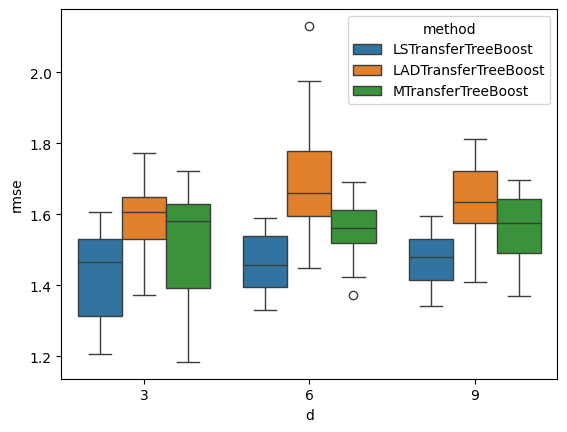

In [32]:
sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

In [10]:
# Here we find the optimal settings
LS_data_slash = data_slash[data_slash['method'] == 'LSTransferTreeBoost']
LAD_data_slash = data_slash[data_slash['method'] == 'LADTransferTreeBoost']
Huber_data_slash = data_slash[data_slash['method'] == 'MTransferTreeBoost']

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_slash,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_slash,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_slash,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

#create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])



Text(0, 0.5, 'RMSE')

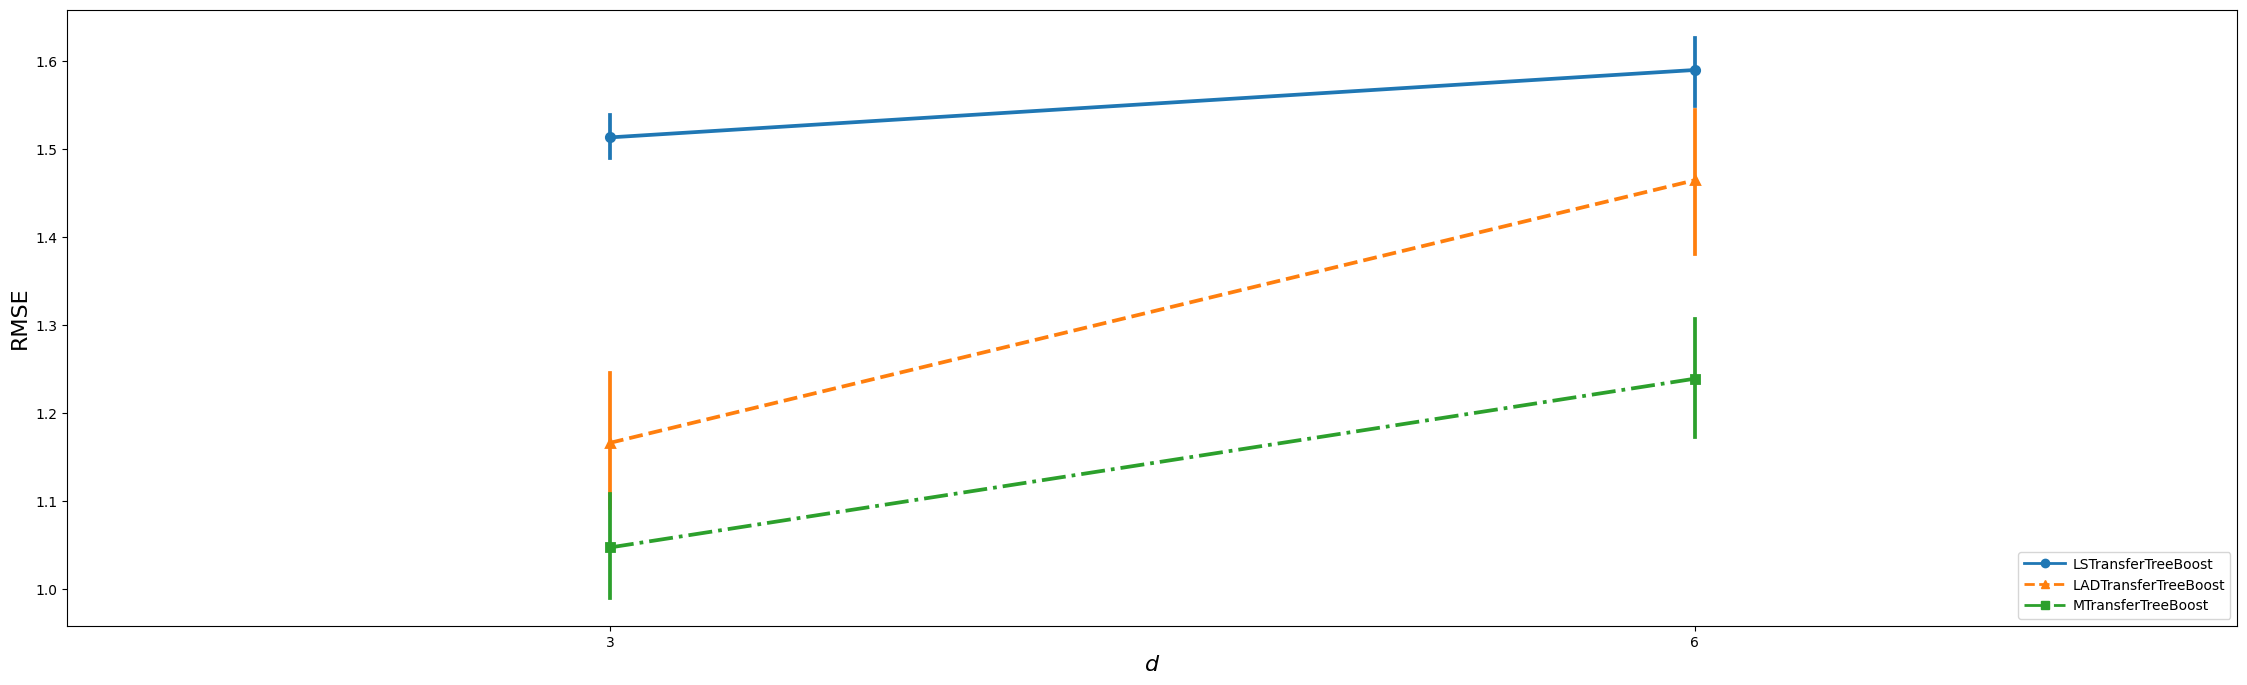

In [11]:
# Plot average test RMSE:s for best hyperparams
from matplotlib.lines import Line2D

plt.figure(figsize = (28,8))
sns.pointplot(data = df, x = 'd', y = 'rmse', hue = 'method', 
                markers=['o', '^', 's', 'D', 'P'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])

# grab the current legend
handles, labels = plt.gca().get_legend_handles_labels()

# rebuild legend with longer lines
new_handles = []
for h in handles:
    if isinstance(h, Line2D):
        new_handles.append(Line2D(
            [0], [0], 
            color=h.get_color(),
            linestyle=h.get_linestyle(),
            marker=h.get_marker(),
            markersize=6,
            linewidth=2,
        ))
    else:
        new_handles.append(h)
#plt.legend(loc="lower right")
plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
plt.gca().set_xlabel('$d$', fontsize=16)
plt.gca().set_ylabel('RMSE', fontsize=16)

<Axes: xlabel='d', ylabel='rmse'>

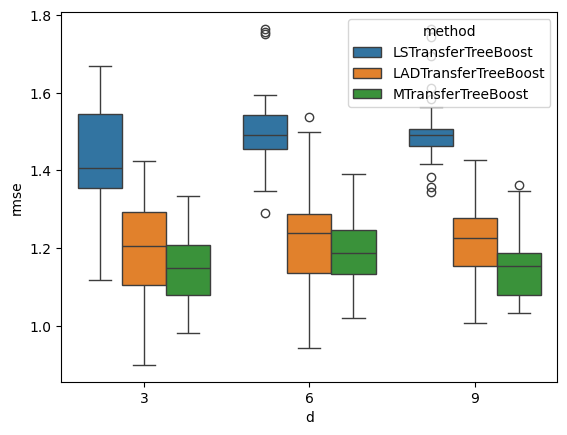

In [35]:
sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

In [12]:
# Here we find the optimal settings
LS_data_t = data_t[data_t['method'] == 'LSTransferTreeBoost']
LAD_data_t = data_t[data_t['method'] == 'LADTransferTreeBoost']
Huber_data_t = data_t[data_t['method'] == 'MTransferTreeBoost']

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_t,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_t,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_t,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

#create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])

Text(0, 0.5, 'RMSE')

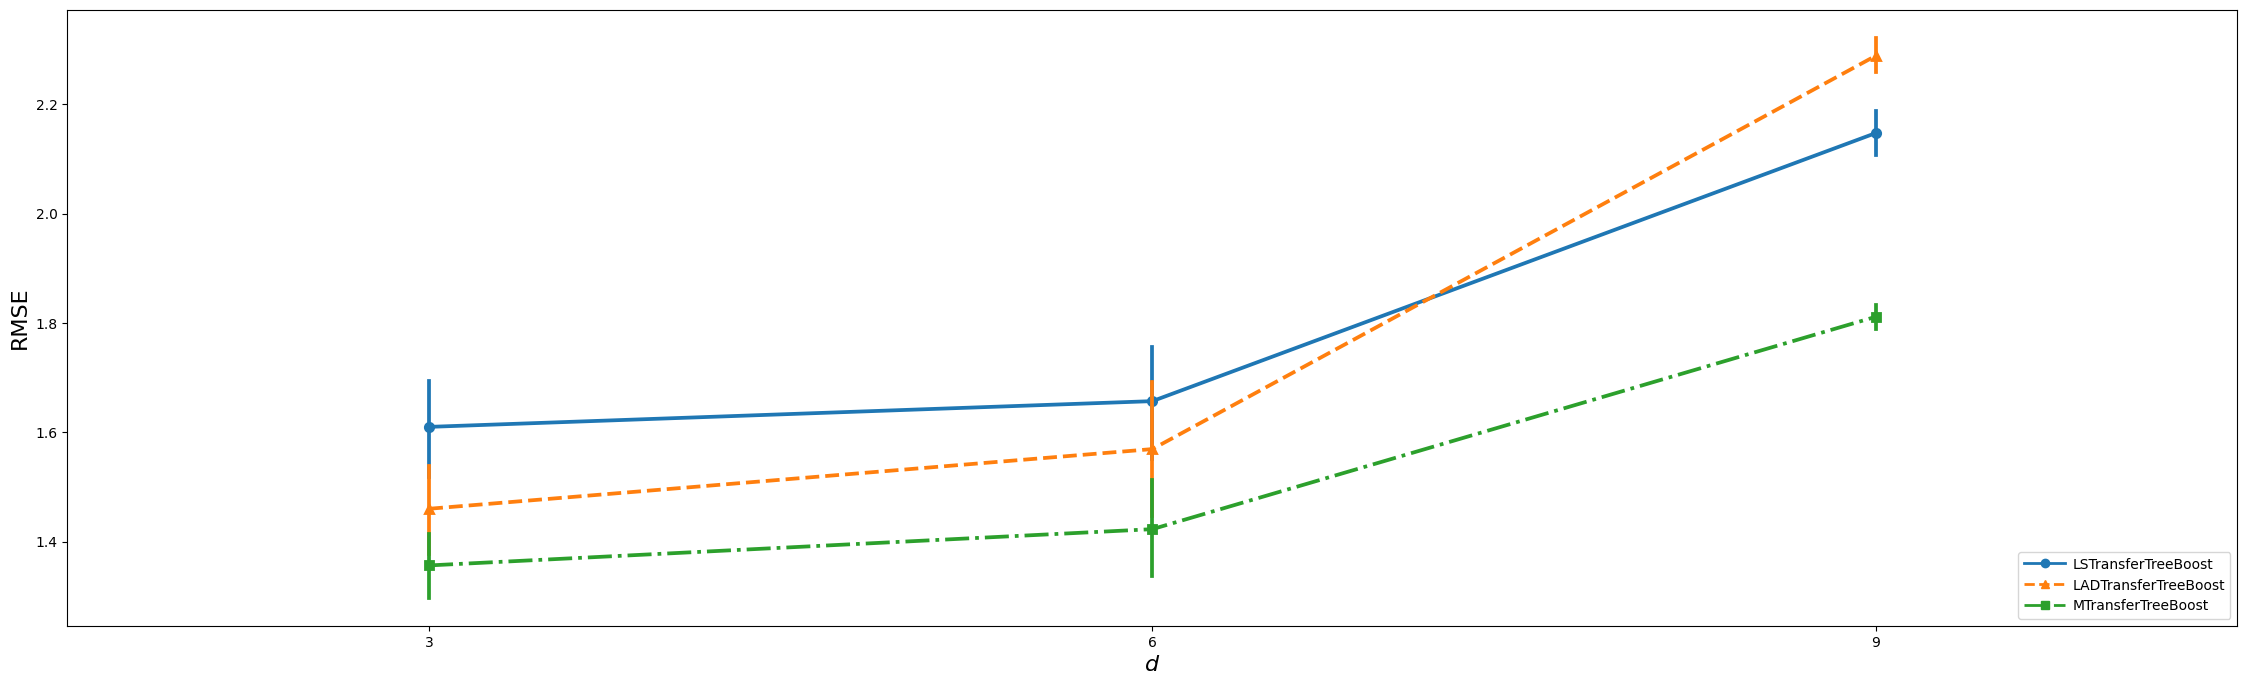

In [13]:
# Plot average test RMSE:s for best hyperparams
from matplotlib.lines import Line2D

plt.figure(figsize = (28,8))
sns.pointplot(data = df, x = 'd', y = 'rmse', hue = 'method', 
                markers=['o', '^', 's', 'D', 'P'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])

# grab the current legend
handles, labels = plt.gca().get_legend_handles_labels()

# rebuild legend with longer lines
new_handles = []
for h in handles:
    if isinstance(h, Line2D):
        new_handles.append(Line2D(
            [0], [0], 
            color=h.get_color(),
            linestyle=h.get_linestyle(),
            marker=h.get_marker(),
            markersize=6,
            linewidth=2,
        ))
    else:
        new_handles.append(h)
#plt.legend(loc="lower right")
plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
plt.gca().set_xlabel('$d$', fontsize=16)
plt.gca().set_ylabel('RMSE', fontsize=16)

<Axes: xlabel='d', ylabel='rmse'>

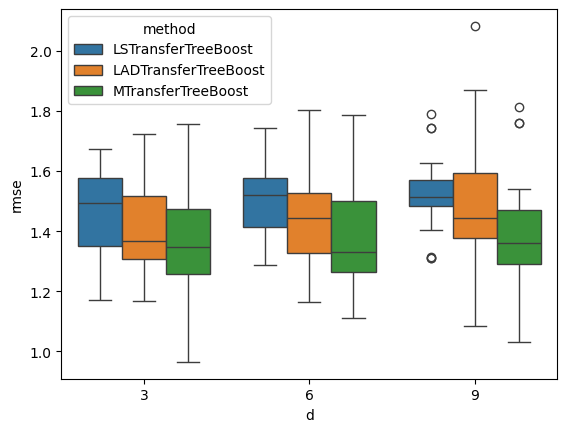

In [38]:
sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

<Axes: xlabel='d', ylabel='rmse'>

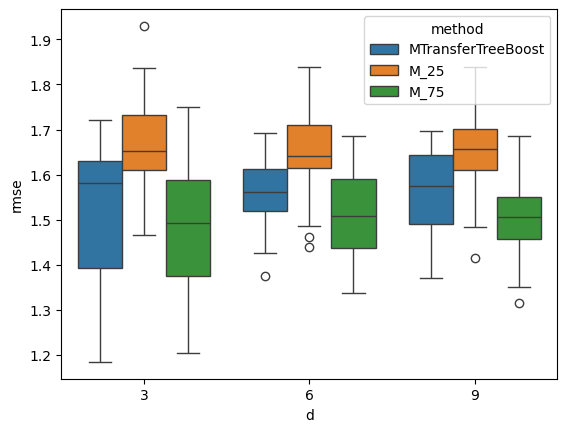

In [39]:
# Here we compare different quantiles for Huber loss
Huber_data_gaussian = data_gaussian[data_gaussian['method'] == 'MTransferTreeBoost'] #read previous result
Huber_data_gaussian_25 = pd.read_csv('results/200_gaussian_025.csv')
Huber_data_gaussian_25['method'] = 'M_25'

Huber_data_gaussian_75 = pd.read_csv('results/200_gaussian_075.csv')
Huber_data_gaussian_75['method'] = 'M_75'

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_gaussian,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_Huber_25, best_Huber_params_25 = topk_per_d_per_method(
    Huber_data_gaussian_25,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_Huber_75, best_Huber_params_75 = topk_per_d_per_method(
    Huber_data_gaussian_75,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

#create new df for viz
df = pd.concat([best_Huber, best_Huber_25])
df = pd.concat([df, best_Huber_75])

sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

#Then repeat in two new cells for Slash, t(2)



<Axes: xlabel='d', ylabel='rmse'>

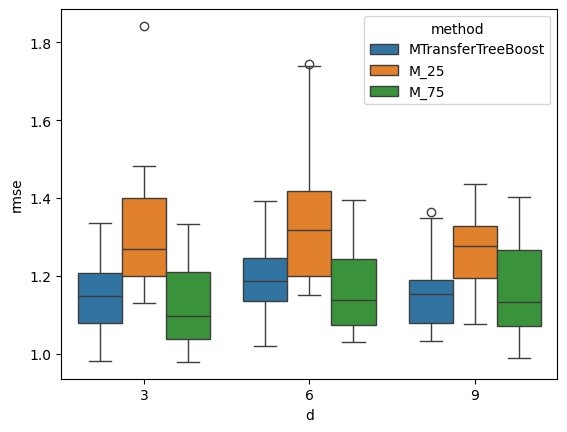

In [40]:
# Here we compare different quantiles for Huber loss
Huber_data_slash = data_slash[data_slash['method'] == 'MTransferTreeBoost'] #read previous result
Huber_data_slash_25 = pd.read_csv('results/200_slash_025.csv')
Huber_data_slash_25['method'] = 'M_25'

Huber_data_slash_75 = pd.read_csv('results/200_slash_075.csv')
Huber_data_slash_75['method'] = 'M_75'

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_slash,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_Huber_25, best_Huber_params_25 = topk_per_d_per_method(
    Huber_data_slash_25,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_Huber_75, best_Huber_params_75 = topk_per_d_per_method(
    Huber_data_slash_75,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

#create new df for viz
df = pd.concat([best_Huber, best_Huber_25])
df = pd.concat([df, best_Huber_75])

sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

<Axes: xlabel='d', ylabel='rmse'>

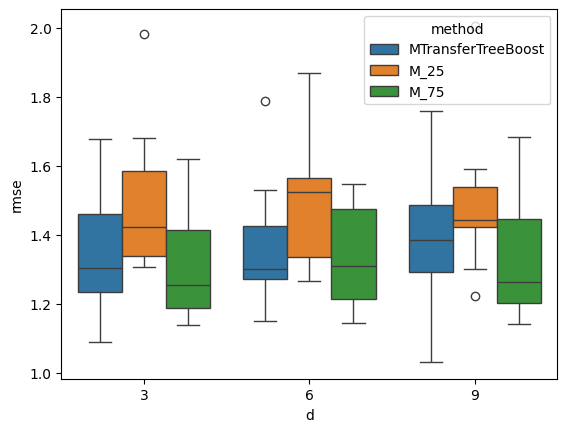

In [41]:
# Here we compare different quantiles for Huber loss
Huber_data_t = data_t[data_t['method'] == 'MTransferTreeBoost'] #read previous result
Huber_data_t_25 = pd.read_csv('results/200_t_025.csv')
Huber_data_t_25['method'] = 'M_25'

Huber_data_t_75 = pd.read_csv('results/200_t_075.csv')
Huber_data_t_75['method'] = 'M_75'

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_t,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=10
)

best_Huber_25, best_Huber_params_25 = topk_per_d_per_method(
    Huber_data_t_25,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=10
)

best_Huber_75, best_Huber_params_75 = topk_per_d_per_method(
    Huber_data_t_75,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=10
)

#create new df for viz
df = pd.concat([best_Huber, best_Huber_25])
df = pd.concat([df, best_Huber_75])

sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

# Here we make final vizes!

In [42]:
# For gaussian errors, we simply combine previous results with LAD results
data_gaussian = pd.read_csv('results/200_gaussian.csv')

# For slash errors
data_slash = pd.read_csv('results/200_slash.csv')

#for t(2) errors
data_t= pd.read_csv('results/200_t.csv')



<Axes: xlabel='d', ylabel='rmse'>

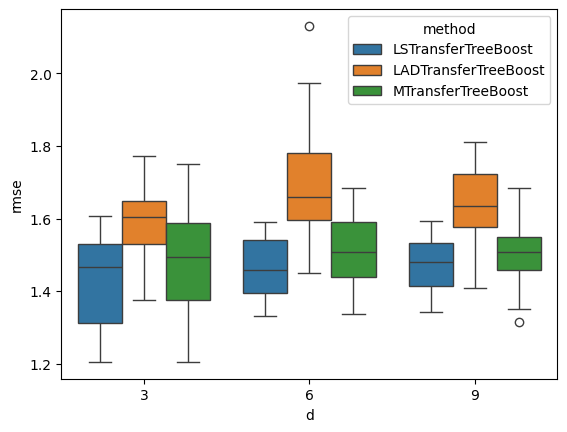

In [43]:
# Here we find the optimal settings
LS_data_gaussian = data_gaussian[data_gaussian['method'] == 'LSTransferTreeBoost']
LAD_data_gaussian = data_gaussian[data_gaussian['method'] == 'LADTransferTreeBoost']
Huber_data_gaussian = pd.read_csv('results/200_gaussian_075.csv')

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_gaussian,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_gaussian,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_gaussian,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

#create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])
sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

<Axes: xlabel='d', ylabel='rmse'>

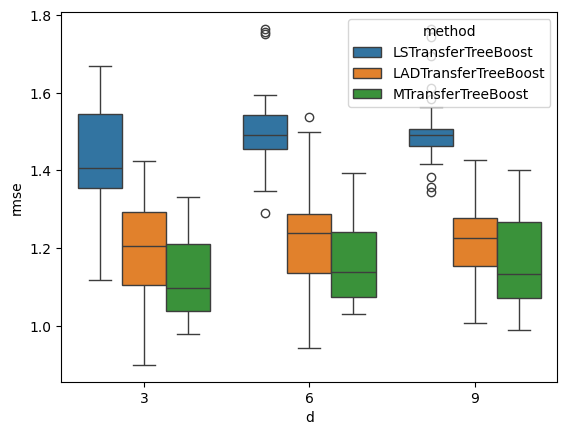

In [44]:
# Here we find the optimal settings
LS_data_slash = data_slash[data_slash['method'] == 'LSTransferTreeBoost']
LAD_data_slash = data_slash[data_slash['method'] == 'LADTransferTreeBoost']
Huber_data_slash = pd.read_csv('results/200_slash_075.csv')

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_slash,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_slash,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_slash,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

# create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])
sns.boxplot(data=df, x='d', y='rmse', hue='method')


C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_12516\2129591848.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LS_data_gaussian['method'] = 'LS'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_12516\2129591848.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LAD_data_gaussian['method'] = 'LAD'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_12516\2129591848.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

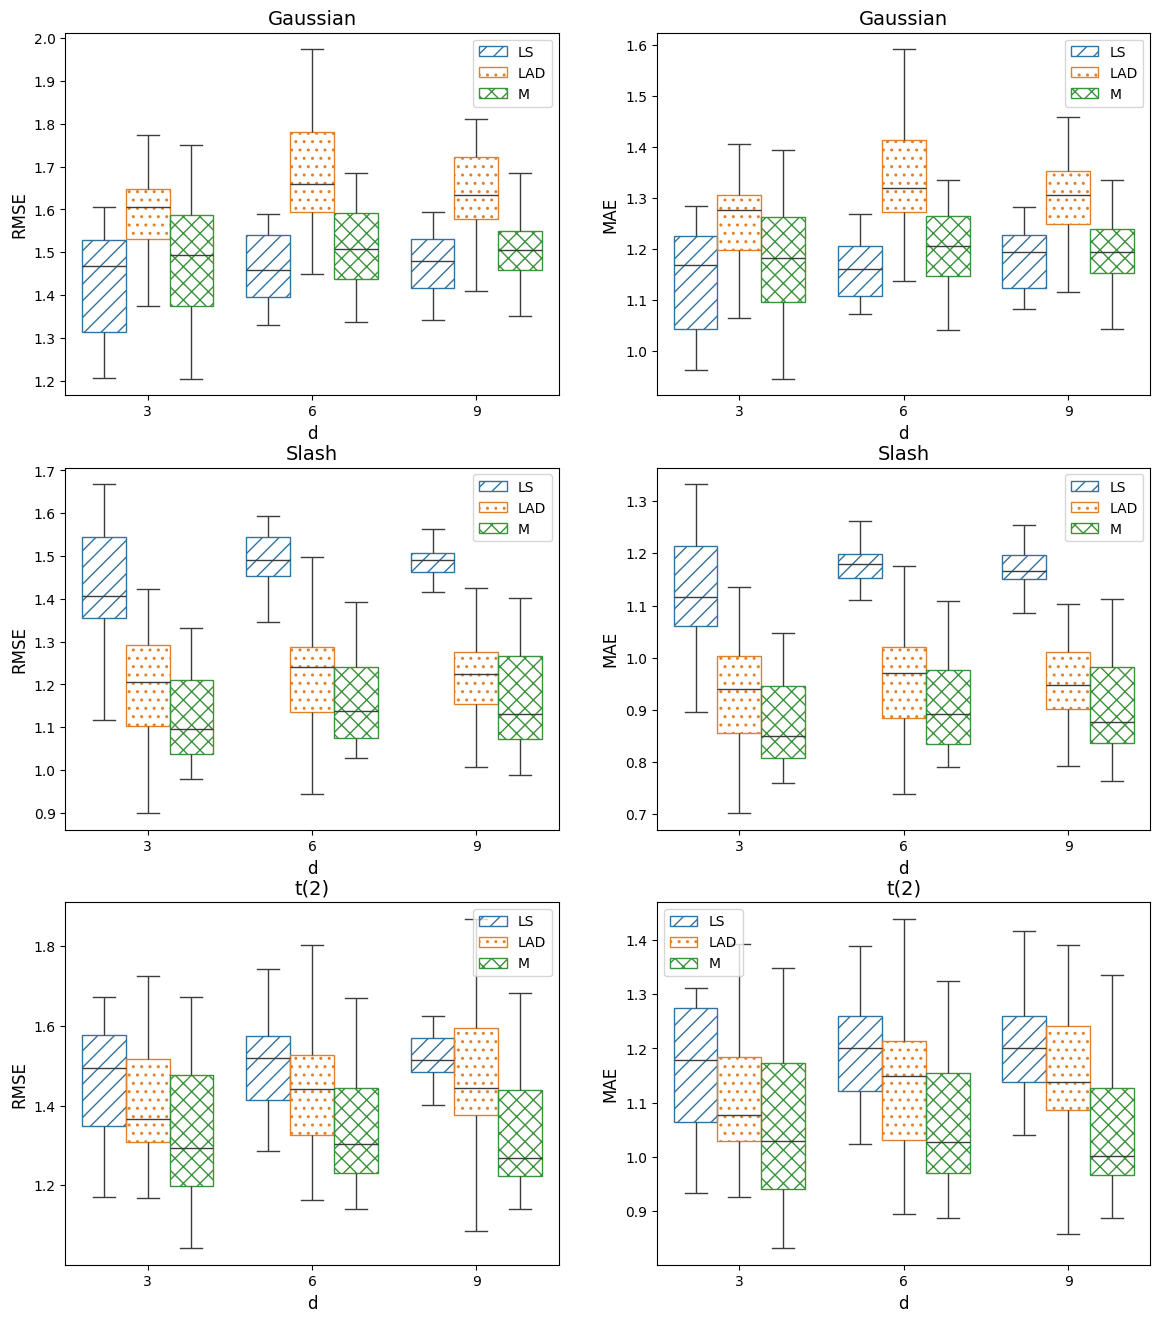

In [55]:

plt.figure(figsize = (14,16))
import matplotlib as mpl
# Here we find the optimal settings
LS_data_gaussian = data_gaussian[data_gaussian['method'] == 'LSTransferTreeBoost']
LAD_data_gaussian = data_gaussian[data_gaussian['method'] == 'LADTransferTreeBoost']
Huber_data_gaussian = pd.read_csv('results/200_gaussian_075.csv')
LS_data_gaussian['method'] = 'LS'
LAD_data_gaussian['method'] = 'LAD'
Huber_data_gaussian['method'] = 'M'

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_gaussian,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_gaussian,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_gaussian,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

# create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])
plt.subplot(3,2,1)
ax = sns.boxplot(x='d', y='rmse', hue='method', data=df, showfliers=False)
plt.title('Gaussian', fontsize = 14)
plt.ylabel('RMSE', fontsize=12)
plt.xlabel('d', fontsize=12)
# hatches must equal the number of hues (3 in this case)
hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# select the correct patches
patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# the number of patches should be evenly divisible by the number of hatches
h = hatches * (len(patches) // len(hatches))
# iterate through the patches for each subplot
for patch, hatch in zip(patches, h):
    patch.set_hatch(hatch)
    fc = patch.get_facecolor()
    patch.set_edgecolor(fc)
    patch.set_facecolor('none')

l = ax.legend()
hatches_in_plot = ['//', '..', 'xx']
for lp, hatch in zip(l.get_patches(), hatches_in_plot):
    lp.set_hatch(hatch)
    fc = lp.get_facecolor()
    lp.set_edgecolor(fc)
    lp.set_facecolor('none')

plt.subplot(3,2,2)
ax = sns.boxplot(x='d', y='mae', hue='method', data=df, showfliers=False)
plt.title('Gaussian', fontsize = 14)
plt.ylabel('MAE', fontsize=12)
plt.xlabel('d', fontsize=12)
# hatches must equal the number of hues (3 in this case)
hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# select the correct patches
patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# the number of patches should be evenly divisible by the number of hatches
h = hatches * (len(patches) // len(hatches))
# iterate through the patches for each subplot
for patch, hatch in zip(patches, h):
    patch.set_hatch(hatch)
    fc = patch.get_facecolor()
    patch.set_edgecolor(fc)
    patch.set_facecolor('none')

l = ax.legend()
hatches_in_plot = ['//', '..', 'xx']
for lp, hatch in zip(l.get_patches(), hatches_in_plot):
    lp.set_hatch(hatch)
    fc = lp.get_facecolor()
    lp.set_edgecolor(fc)
    lp.set_facecolor('none')


# Here we find the optimal settings
LS_data_slash = data_slash[data_slash['method'] == 'LSTransferTreeBoost']
LAD_data_slash = data_slash[data_slash['method'] == 'LADTransferTreeBoost']
Huber_data_slash = pd.read_csv('results/200_slash_075.csv')
LS_data_slash['method'] = 'LS'
LAD_data_slash['method'] = 'LAD'
Huber_data_slash['method'] = 'M'

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_slash,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_slash,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_slash,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

# create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])
plt.subplot(3,2,3)
ax = sns.boxplot(x='d', y='rmse', hue='method', data=df, showfliers=False)
plt.title('Slash', fontsize = 14)
plt.ylabel('RMSE', fontsize=12)
plt.xlabel('d', fontsize=12)
# hatches must equal the number of hues (3 in this case)
hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# select the correct patches
patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# the number of patches should be evenly divisible by the number of hatches
h = hatches * (len(patches) // len(hatches))
# iterate through the patches for each subplot
for patch, hatch in zip(patches, h):
    patch.set_hatch(hatch)
    fc = patch.get_facecolor()
    patch.set_edgecolor(fc)
    patch.set_facecolor('none')

l = ax.legend()
hatches_in_plot = ['//', '..', 'xx']
for lp, hatch in zip(l.get_patches(), hatches_in_plot):
    lp.set_hatch(hatch)
    fc = lp.get_facecolor()
    lp.set_edgecolor(fc)
    lp.set_facecolor('none')

plt.subplot(3,2,4)
ax = sns.boxplot(x='d', y='mae', hue='method', data=df, showfliers=False)
plt.title('Slash', fontsize = 14)
plt.ylabel('MAE', fontsize=12)
plt.xlabel('d', fontsize=12)
# hatches must equal the number of hues (3 in this case)
hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# select the correct patches
patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# the number of patches should be evenly divisible by the number of hatches
h = hatches * (len(patches) // len(hatches))
# iterate through the patches for each subplot
for patch, hatch in zip(patches, h):
    patch.set_hatch(hatch)
    fc = patch.get_facecolor()
    patch.set_edgecolor(fc)
    patch.set_facecolor('none')

l = ax.legend()
hatches_in_plot = ['//', '..', 'xx']
for lp, hatch in zip(l.get_patches(), hatches_in_plot):
    lp.set_hatch(hatch)
    fc = lp.get_facecolor()
    lp.set_edgecolor(fc)
    lp.set_facecolor('none')


# Here we find the optimal settings
LS_data_t = data_t[data_t['method'] == 'LSTransferTreeBoost']
LAD_data_t = data_t[data_t['method'] == 'LADTransferTreeBoost']
Huber_data_t = pd.read_csv('results/200_t_075.csv')
LS_data_t['method'] = 'LS'
LAD_data_t['method'] = 'LAD'
Huber_data_t['method'] = 'M'

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_t,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_t,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_t,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
)

# create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])
plt.subplot(3,2,5)
ax = sns.boxplot(x='d', y='rmse', hue='method', data=df, showfliers=False)
plt.title('t(2)', fontsize = 14)
plt.ylabel('RMSE', fontsize=12)
plt.xlabel('d', fontsize=12)
# hatches must equal the number of hues (3 in this case)
hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# select the correct patches
patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# the number of patches should be evenly divisible by the number of hatches
h = hatches * (len(patches) // len(hatches))
# iterate through the patches for each subplot
for patch, hatch in zip(patches, h):
    patch.set_hatch(hatch)
    fc = patch.get_facecolor()
    patch.set_edgecolor(fc)
    patch.set_facecolor('none')

l = ax.legend()
hatches_in_plot = ['//', '..', 'xx']
for lp, hatch in zip(l.get_patches(), hatches_in_plot):
    lp.set_hatch(hatch)
    fc = lp.get_facecolor()
    lp.set_edgecolor(fc)
    lp.set_facecolor('none')

plt.subplot(3,2,6)
ax = sns.boxplot(x='d', y='mae', hue='method', data=df, showfliers=False)
plt.title('t(2)', fontsize = 14)
plt.ylabel('MAE', fontsize=12)
plt.xlabel('d', fontsize=12)
# hatches must equal the number of hues (3 in this case)
hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# select the correct patches
patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# the number of patches should be evenly divisible by the number of hatches
h = hatches * (len(patches) // len(hatches))
# iterate through the patches for each subplot
for patch, hatch in zip(patches, h):
    patch.set_hatch(hatch)
    fc = patch.get_facecolor()
    patch.set_edgecolor(fc)
    patch.set_facecolor('none')

l = ax.legend()
hatches_in_plot = ['//', '..', 'xx']
for lp, hatch in zip(l.get_patches(), hatches_in_plot):
    lp.set_hatch(hatch)
    fc = lp.get_facecolor()
    lp.set_edgecolor(fc)
    lp.set_facecolor('none')

plt.savefig('vizes/esann_viz.png', bbox_inches = 'tight', pad_inches = 0.05, dpi = 300)


# Final viz comes here!!!!
data = pd.read_csv('results/200_gaussian_6_optim.csv')
data_slash = pd.read_csv('results/200_slash_6_optim.csv')
# We remove one very weird result. As this did not happen in any other experiment, 
# we believe this is a numerical issue with the code. We remove the seed for both methods.
data = data[data['seed'] != 18] 
data_slash = data_slash[data_slash['seed'] != 18]
data['method'] = data['method'].replace("LSTransferTreeBoost", "LS")
data['method'] = data['method'].replace("LADTransferTreeBoost", "LAD")

data_slash['method'] = data_slash['method'].replace("LSTransferTreeBoost", "LS")
data_slash['method'] = data_slash['method'].replace("LADTransferTreeBoost", "LAD")

plt.figure(figsize = (14,10))

plt.subplot(2,2,1)
sns.boxplot(data = data, x = 'method', y = 'rmse')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('RMSE', fontsize=14)
plt.gca().set_title('Gaussian', fontsize=16)

plt.subplot(2,2,2)
sns.boxplot(data = data, x = 'method', y = 'mae')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('MAE', fontsize=14)
plt.gca().set_title('Gaussian', fontsize=16)

plt.subplot(2,2,3)
sns.boxplot(data = data_slash, x = 'method', y = 'rmse')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('RMSE', fontsize=14)
plt.gca().set_title('Slash', fontsize=16)

plt.subplot(2,2,4)
sns.boxplot(data = data_slash, x = 'method', y = 'mae')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('MAE', fontsize=14)
plt.gca().set_title('Slash', fontsize=16)

plt.savefig('vizes/ls-lad.png', dpi = 300, bbox_inches = 'tight', pad_inches = 0.1)







In [46]:
best_Huber_params[0:40]

,d,v,source_tree_size,target_tree_size,m_0,k,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,method,epochs,val_rmse,val_mae,rmse,mae
21,3,0.075,1,2,0.9,0.01,1.306181,1.029892,10,53,71,M,1000,1.518713,1.217719,1.552638,1.252592
37,3,0.075,1,2,0.9,0.01,1.306181,1.029892,10,101,72,M,1000,1.366730,1.083351,1.439190,1.134210
69,3,0.075,1,2,0.9,0.01,1.306181,1.029892,10,197,74,M,1000,1.123246,0.896378,1.207743,0.958918
53,3,0.075,1,2,0.9,0.01,1.306181,1.029892,10,149,73,M,1000,1.337446,1.044258,1.337496,1.047458
117,3,0.075,1,2,0.9,0.01,1.306181,1.029892,10,341,77,M,1000,1.604716,1.262085,1.619244,1.284495
133,3,0.075,1,2,0.9,0.01,1.306181,1.029892,10,389,78,M,1000,1.250631,0.969007,1.217356,0.961685
101,3,0.075,1,2,0.9,0.01,1.306181,1.029892,10,293,76,M,1000,1.181884,0.916771,1.162502,0.907036
85,3,0.075,1,2,0.9,0.01,1.306181,1.029892,10,245,75,M,1000,1.219800,0.944868,1.181466,0.918725
5,3,0.075,1,2,0.9,0.01,1.306181,1.029892,10,5,70,M,1000,1.162020,0.918200,1.137808,0.895490
149,3,0.075,1,2,0.9,0.01,1.306181,1.029892,10,437,79,M,1000,1.296618,1.046279,1.288461,1.036311
